In [1]:
import pulp
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from src.dynamic_pricing_data_loader import cargar_y_preparar_datos
from Tools.ExtractData import GetDataFromETL
import seaborn as sns

# Costos operativos

En esta sección se define los costos operativos para poder tener una idea de cuánto se debe recuperar de la inversión inicial

In [2]:
def calcular_costos_operativos(distancia, costo_km, capacidad, ocupacion_esperada, margen_utilidad=0.16):
    """
    Fase 1: Cálculo del Costo Base y Precio Piso.
    Esta función calcula cuánto debe costar cada boleto para cubrir
    los gastos de la corrida y asegurar una utilidad mínima.
    """
    
    # Cálculo del costo total operativo (Gasto fijo)
    costo_total = distancia * costo_km
    
    # Número de asientos que se proyectan vender (Capacidad * Ocupación)
    asientos_vendidos = capacidad * ocupacion_esperada
    
    # Validación: Evitar división por cero si la ocupación es nula
    if asientos_vendidos <= 0:
        return {"error": "La ocupación esperada debe ser mayor a 0 para calcular un precio por asiento."}
    
    # Precio mínimo por asiento para cubrir el costo operativo + margen de utilidad
    # Fórmula: (Costo Total * (1 + Margen)) / Asientos Vendidos
    precio_piso = (costo_total * (1 + margen_utilidad)) / asientos_vendidos
    
    return {
        "costo_total": round(costo_total, 2),
        "precio_piso_minimo": round(precio_piso, 2),
        "asientos_a_vender": int(asientos_vendidos)
    }

# --- EJEMPLO DE USO ---
# Ingresa aquí tus datos reales:
distancia_ruta = 520     # KM de la ruta
costo_por_km = 40        # Gasto operativo por km
capacidad_bus = 36      # Asientos totales
ocupacion_proyectada = 0.50 # 70% de ocupación (0.70)

resultados = calcular_costos_operativos(distancia_ruta, costo_por_km, capacidad_bus, ocupacion_proyectada)

print("--- RESULTADOS FASE 1: FUNDAMENTOS FINANCIEROS ---")
print(f"Costo total del viaje: ${resultados['costo_total']}")
print(f"Asientos proyectados a vender: {resultados['asientos_a_vender']}")
print(f"Precio piso mínimo por boleto: ${resultados['precio_piso_minimo']}")
print(f"Recuperacion: ${resultados['precio_piso_minimo']*resultados['asientos_a_vender']}")

--- RESULTADOS FASE 1: FUNDAMENTOS FINANCIEROS ---
Costo total del viaje: $20800
Asientos proyectados a vender: 18
Precio piso mínimo por boleto: $1340.44
Recuperacion: $24127.920000000002


# Encontrar pasajeros óptimos

En esta sección se encuentra cuántos pasajeros adultos necesitamos para resarcir los descuentos, el sobrante de pasajeros son descuentos

In [3]:
import pulp
import pandas as pd

def optimizar_mix_pasajeros_real(costo_operativo, capacidad_total, tarifa_adulto, descuentos):
    # --- LIMPIEZA DE DATOS (Evita el TypeError) ---
    def a_escalar(valor):
        # Si es una lista, array o Serie de pandas, extrae el primer elemento
        if hasattr(valor, '__iter__') and not isinstance(valor, dict):
            return float(valor[0])
        return float(valor)

    try:
        costo_operativo = a_escalar(costo_operativo)
        capacidad_total = int(a_escalar(capacidad_total))
        tarifa_adulto = a_escalar(tarifa_adulto)
    except Exception as e:
        return f"Error en el formato de los datos de entrada: {e}"

    # --- INICIO DEL MODELO ---
    prob = pulp.LpProblem("Llenar_Autobus_Rentable", pulp.LpMaximize)

    # Variables
    adultos = pulp.LpVariable('Adultos', lowBound=0, cat='Integer')
    
    # Variables de descuento con mínimos de ley
    vars_descuento = {}
    for tipo, info in descuentos.items():
        # Obligar a que INSEN y Niños sean >= 1
        piso_minimo = 1 if tipo.lower() in ['insen', 'ninos'] else 0
        
        vars_descuento[tipo] = pulp.LpVariable(
            tipo, 
            lowBound=piso_minimo, 
            upBound=info['limite'], 
            cat='Integer'
        )

    # --- FUNCIÓN OBJETIVO ---
    # Maximizamos pasajeros totales. 
    # Le damos un peso ínfimo extra al adulto (0.001) solo para priorizar ingreso en empates
    prob += adultos + pulp.lpSum([vars_descuento[t] for t in descuentos])

    # --- RESTRICCIONES ---
    # 1. Ingreso total >= costo operativo
    # Aquí es donde fallaba antes si tarifa_adulto era una lista
    ingreso_total = (adultos * tarifa_adulto) + \
                    pulp.lpSum([vars_descuento[t] * (tarifa_adulto * descuentos[t]['factor']) for t in descuentos])
    
    prob += ingreso_total >= costo_operativo
    
    # 2. Capacidad máxima
    prob += adultos + pulp.lpSum([vars_descuento[t] for t in descuentos]) <= capacidad_total

    # Resolver
    prob.solve(pulp.PULP_CBC_CMD(msg=0))

    # Verificación de resultados
    if pulp.LpStatus[prob.status] != 'Optimal':
        return "Infactible"
        
    return {
        "Adultos": int(adultos.varValue),
        "Descuentos": {t: int(vars_descuento[t].varValue) for t in descuentos},
        "Total_Pasajeros": int(pulp.value(adultos + pulp.lpSum([vars_descuento[t] for t in descuentos]))),
        "Ingreso_Final": round(pulp.value(ingreso_total), 2),
        "Costo_a_Cubrir": costo_operativo,
        "Estado": pulp.LpStatus[prob.status]
    }

# Optimizacion de precio

En esta seccion se quiere encontrar el precio más barato para obtener la inversión inicial con al menos un insen y un niño abordo.

In [4]:
def optimizar_precio(distancia, costo_km, capacidad, ocupacion_esperada):
    margen_utilidad=0.16
    # Cálculo del costo total operativo (Gasto fijo)
    costo_total = distancia * costo_km
    
    # Número de asientos que se proyectan vender (Capacidad * Ocupación)
    asientos_parciales = capacidad * ocupacion_esperada

    # Precio mínimo parcial por asiento para cubrir el costo operativo + margen de utilidad
    precio_parcial = (costo_total * (1 + margen_utilidad)) / asientos_parciales
    # Precio mínimo total por asiento para cubrir el costo operativo + margen de utilidad si vendes todos los asientos
    precio_total = (costo_total * (1 + margen_utilidad)) / capacidad
    
    limites_ley = {
        'estudiantes': {'factor': 0.85, 'limite': 2},
        'insen': {'factor': 0.5, 'limite': 2},
        'maestros': {'factor': 0.75, 'limite': 2},
        'ninos': {'factor': 0.5, 'limite': 2},
        'empleado_gobierno': {'factor': 0.90, 'limite': 2}
    }
    
    precios = np.round(np.linspace(precio_total, precio_parcial, 200),0)
    preciosf=[]
    for prize in precios:
        resultado = optimizar_mix_pasajeros_real(costo_total, asientos_parciales, prize, limites_ley)
        if not resultado == "Infactible":
            preciosf.append(prize)
    return min(preciosf)

PrecioOptimo= optimizar_precio(distancia_ruta, costo_por_km, capacidad_bus, ocupacion_proyectada)
resultados['PrecioOptimo']=PrecioOptimo
print(f"Recuperacion de {resultados['asientos_a_vender']} asientos a {resultados['asientos_a_vender']} es :${PrecioOptimo*resultados['asientos_a_vender']}")
print(f"Precio Optimo: ${PrecioOptimo} vs Precio Minimo piso {resultados['precio_piso_minimo']}")

Recuperacion de 18 asientos a 18 es :$22068.0
Precio Optimo: $1226.0 vs Precio Minimo piso 1340.44


In [5]:
# --- TU BLOQUE DE EJECUCIÓN ---
# Asegúrate de que estas variables existan en tu notebook
costo = resultados['costo_total']
capacidad = resultados['asientos_a_vender']
tarifa = PrecioOptimo

limites_ley = {
    'estudiantes': {'factor': 0.85, 'limite': 2},
    'insen': {'factor': 0.5, 'limite': 2},
    'maestros': {'factor': 0.75, 'limite': 2},
    'ninos': {'factor': 0.5, 'limite': 2},
    'empleado_gobierno': {'factor': 0.90, 'limite': 2}
}

resultado = optimizar_mix_pasajeros_real(costo, capacidad, tarifa, limites_ley)
print(resultado)

{'Adultos': 16, 'Descuentos': {'estudiantes': 0, 'insen': 1, 'maestros': 0, 'ninos': 1, 'empleado_gobierno': 0}, 'Total_Pasajeros': 18, 'Ingreso_Final': 20842.0, 'Costo_a_Cubrir': 20800.0, 'Estado': 'Optimal'}


# Regla de precio

In [6]:
def GetPrize(Tarifa,PrecioPiso, Rango):
    orden_rangos = [
        '+90 días', '2-3 meses', '1-2 meses', '2-4 semanas', '1-2 semanas', 
        '3-7 días', '1-3 días', '12-24 hrs', '6-12 hrs', '3-6 hrs', '1-3 hrs', '0-1 hrs'
    ]

    if Rango in orden_rangos[:4]:
        return float(Tarifa)
    elif Rango in orden_rangos[4:9]:
        return 0.45*float(Tarifa)+0.55*PrecioPiso
    elif Rango in orden_rangos[9:]:
        return PrecioPiso

In [7]:
orden_rangos = [
        '+90 días', '2-3 meses', '1-2 meses', '2-4 semanas', '1-2 semanas', 
        '3-7 días', '1-3 días', '12-24 hrs', '6-12 hrs', '3-6 hrs', '1-3 hrs', '0-1 hrs'
    ]

GetPrize(tarifa,resultados['precio_piso_minimo'], orden_rangos[-1])

1340.44

# Curvas pick up

En esta sección se calcula un promedio de las curvas de cada ruta, horario para encontrar como se comporta la demanda a lo largo del tiempo de anticipación

In [8]:
def procesar_ocupacion_dinamica_v2(df_input, col_capacidad='Q'):
    # 1. Configuración de parámetros
    bins = [-np.inf, 0, 1, 3, 6, 12, 24, 72, 168, 336, 720, 1440, 2160, np.inf]
    labels = ['Post-Salida', '0-1 hrs', '1-3 hrs', '3-6 hrs', '6-12 hrs', '12-24 hrs', 
              '1-3 días', '3-7 días', '1-2 semanas', '2-4 semanas', '1-2 meses', '2-3 meses', '+90 días']
    orden_rangos = labels[::-1]

    # Pre-cálculo y optimización
    df_input = df_input.copy()
    df_input['Q'] = df_input['PAX_SUBEN'] + df_input['DISPONIBILIDAD_TRAMO']
    df_input.loc[df_input['Q'] <= 0, 'Q'] = df_input['CAPACIDAD_ASIENTOS_TRAMO']
    df_input['HORA_ENTERA'] = df_input['HORA_ENTERA'].astype(int).astype('int8')

    # 2. Pipeline de procesamiento
    df_result = (
        df_input.drop_duplicates().assign(
            CV_CORRIDA = lambda x: x['CV_CORRIDA'].astype(str),
            RANGO_ANTICIPACION = lambda x: pd.Categorical(
                pd.cut(x['HORAS_ANTICIPACION'], bins=bins, labels=labels),
                categories=orden_rangos, ordered=True
            )
        )
        .query("BOLETOS_VEND > 0 & RANGO_ANTICIPACION != 'Post-Salida'")
        .groupby(['ORIGEN_DESTINO', 'CV_CORRIDA', 'FECHA_CORRIDA', 'HORA_ENTERA', 'RANGO_ANTICIPACION'], observed=True)
        .agg(
            BOLETOS_VEND=('BOLETOS_VEND', 'sum'), 
            CAPACIDAD_ORIGINAL=(col_capacidad, 'mean'),
            Ingreso=('VENTA','sum'),
            Tarifa=('TARIFA_BASE_TRAMO','sum')
        )
        .reset_index()
        .sort_values(['CV_CORRIDA', 'FECHA_CORRIDA', 'HORA_ENTERA', 'RANGO_ANTICIPACION'])
    )

    
    # 3. Cálculos Dinámicos - SUMA ACUMULADA DE OCUPACIÓN
    group = df_result.groupby(['CV_CORRIDA', 'FECHA_CORRIDA', 'HORA_ENTERA'])

    # Venta acumulada (Numerador)
    df_result['VENTA_ACUMULADA'] = group['BOLETOS_VEND'].cumsum()

    # Venta previa para capacidad dinámica (Informativo)
    df_result['VENTA_PREVIA_ACUM'] = group['BOLETOS_VEND'].shift(1, fill_value=0).cumsum()
    df_result['CAPACIDAD_DINAMICA'] = (df_result['CAPACIDAD_ORIGINAL'] - df_result['VENTA_PREVIA_ACUM']).clip(lower=0)

    # --- CORRECCIÓN: OCUPACIÓN ACUMULADA SIGUIENDO EL CRITERIO DE VENTA ---
    # 1. Calculamos cuánto representa ESTA venta del rango actual sobre el TOTAL del bus
    df_result['OCUPACION_INDIVIDUAL_%'] = (df_result['BOLETOS_VEND'] / df_result['CAPACIDAD_ORIGINAL']) * 100
    
    # 2. Hacemos la suma acumulada de esos porcentajes por grupo
    df_result['OCUPACION_ACUMULADA_%'] = group['OCUPACION_INDIVIDUAL_%'].cumsum()
    # ----------------------------------------------------------------------

    # 4. Resumen para gráfica
    df_plot = (
        df_result.groupby(['ORIGEN_DESTINO', 'HORA_ENTERA', 'RANGO_ANTICIPACION'], observed=True)
        ['OCUPACION_ACUMULADA_%']
        .mean()
        .reset_index()
    )

    df_plot1 = (
        df_result.groupby(['ORIGEN_DESTINO', 'RANGO_ANTICIPACION'], observed=True)
        ['OCUPACION_ACUMULADA_%']
        .mean()
        .reset_index()
    )

    
    return df_result, df_plot,df_plot1


In [9]:
def GraficarOcupacion(df_plot):
    # 1. Definición del orden lógico (Pasado -> Presente)
    orden_rangos = [
        '+90 días', '2-3 meses', '1-2 meses', '2-4 semanas', '1-2 semanas', 
        '3-7 días', '1-3 días', '12-24 hrs', '6-12 hrs', '3-6 hrs', 
        '1-3 hrs', '0-1 hrs', 'Post-Salida'
    ]
    
    # Trabajamos sobre una copia para no afectar el dataframe original fuera de la función
    df_temp = df_plot.copy()

    # 2. CONVERTIR A CATEGORÍA ORDENADA
    # Esto le dice a Python que '1-2 semanas' SIEMPRE va antes que '1-3 días'
    df_temp['RANGO_ANTICIPACION'] = pd.Categorical(
        df_temp['RANGO_ANTICIPACION'], 
        categories=orden_rangos, 
        ordered=True
    )

    # 3. ORDENAR FÍSICAMENTE EL DATAFRAME
    # Ordenamos por ruta y luego por el orden lógico que definimos arriba
    df_temp = df_temp.sort_values(['ORIGEN_DESTINO', 'RANGO_ANTICIPACION'])

    # 4. Configuración estética
    plt.figure(figsize=(15, 8))
    sns.set_style("whitegrid")
    
    # 5. Dibujar las líneas
    # Ahora sort=True (por defecto) funcionará perfecto porque el DF ya está ordenado
    plot = sns.lineplot(
        data=df_temp, 
        x='RANGO_ANTICIPACION', 
        y='OCUPACION_ACUMULADA_%', 
        hue='ORIGEN_DESTINO', 
        marker='o',
        linewidth=2,
        markersize=7
    )
    
    # 6. Ajustes finales de formato
    plt.title('Curva de Llenado de Autobús (Pickup) por Ruta', fontsize=16, fontweight='bold')
    plt.xlabel('Ventana de Anticipación (De mayor a menor)', fontsize=12)
    plt.ylabel('% Ocupación Acumulada Promedio', fontsize=12)
    
    # Rotar etiquetas para que no se amontonen
    plt.xticks(rotation=45)
    
    # Límites lógicos y rejilla
    plt.ylim(0, 105) 
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Leyenda fuera del gráfico para que no estorbe
    plt.legend(title='Rutas (Origen-Destino)', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()


In [10]:
def GraficarOcupacionPorHora(df_plot, hora_seleccionada):
    # 1. Definición del orden lógico
    orden_rangos = [
        '+90 días', '2-3 meses', '1-2 meses', '2-4 semanas', '1-2 semanas', 
        '3-7 días', '1-3 días', '12-24 hrs', '6-12 hrs', '3-6 hrs', '1-3 hrs', '0-1 hrs'
    ]
    
    # 2. Filtrado
    df_filtrado = df_plot[df_plot['HORA_ENTERA'] == hora_seleccionada].copy()
    
    if df_filtrado.empty:
        print(f"❌ ERROR: No se encontraron datos para la hora {hora_seleccionada}:00")
        return

    # --- LA CORRECCIÓN CLAVE AQUÍ ---
    # Convertimos la columna a Categorical con el orden lógico predefinido
    df_filtrado['RANGO_ANTICIPACION'] = pd.Categorical(
        df_filtrado['RANGO_ANTICIPACION'], 
        categories=orden_rangos, 
        ordered=True
    )
    
    # Ordenamos el dataframe físicamente por Ruta y luego por el Rango de Anticipación
    df_filtrado = df_filtrado.sort_values(['ORIGEN_DESTINO', 'RANGO_ANTICIPACION'])
    # --------------------------------

    # 3. Configuración estética
    plt.figure(figsize=(15, 8))
    sns.set_style("whitegrid")
    
    # 4. Creación del gráfico
    # Ahora sort=True funcionará correctamente porque definimos el orden categórico
    plot = sns.lineplot(
        data=df_filtrado, 
        x='RANGO_ANTICIPACION', 
        y='OCUPACION_ACUMULADA_%', 
        hue='ORIGEN_DESTINO', 
        marker='o',
        linewidth=2.5,
        markersize=8,
        sort=True  
    )
    
    plt.title(f'Curva de Llenado (Pickup) - Salidas: {hora_seleccionada}:00 hrs', fontsize=16, fontweight='bold')
    plt.xlabel('Ventana de Anticipación (Venta previa)', fontsize=12)
    plt.ylabel('% Ocupación Acumulada', fontsize=12)
    
    # Ajustar el eje X para que no muestre rangos vacíos si no quieres, 
    # o dejarlos todos para ver el hueco de ventas.
    plt.xticks(rotation=45)
    plt.ylim(0, 105) 
    
    plt.legend(title='Rutas (Origen-Destino)', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


# Fase de entrenado

Aquí se calculan las curvas promedio con las cuales se va a comparar las ventas actuales

In [11]:
Data= GetDataFromETL(True)
df=Data.Frame
df['FECHA_CORRIDA']=pd.to_datetime(df['FECHA_CORRIDA'])
df['HORA_SALIDA_CORRIDA']=pd.to_datetime(df['HORA_SALIDA_CORRIDA'])

El archivo JSON ha sido actualizado con las nuevas rutas.
Memoria usada antes: 2880.12 MB
Memoria usada después: 562.47 MB
Reducción: 80.5%


In [12]:
# --- Preparación de datos fuera de la función ---
Df_2 = df.copy()
acla_keys = ['PF', 'AD', 'ES', 'IN', 'MA', 'NI', 'PD', 'PE', 'XA', 'ZA', 'ZB', 'VC', 'PH', 'FA', 'OD', 'XP', 'IF', 'SC']
porcentaje_values = [25, 0, 50, 50, 25, 50, 25, 0, 5, 0, 10, 25, 6, 0, 50, 25, 0, 0]

# Crear el diccionario (Mapeo de código a porcentaje entero)
diccionario_acla_porcentaje = dict(zip(acla_keys, porcentaje_values))
Df_2['Descuento'] = Df_2['TIPO_PASAJERO'].map(diccionario_acla_porcentaje) / 100

Df_2['VENTA'] = np.where(
    Df_2['VENTA'] == 0, 
    Df_2['TARIFA_BASE_TRAMO'] * (1 - Df_2['Descuento']), 
    Df_2['VENTA'] # Mantiene el valor original si no es 0
)

FechaFinal = df['FECHA_CORRIDA'].max() - pd.Timedelta(days=30)

# Extraer hora y filtrar
Df_2['HORA_ENTERA'] = pd.to_datetime(Df_2['HORA_SALIDA_CORRIDA']).dt.hour
Df = Df_2[Df_2['FECHA_CORRIDA'] <= FechaFinal].copy()

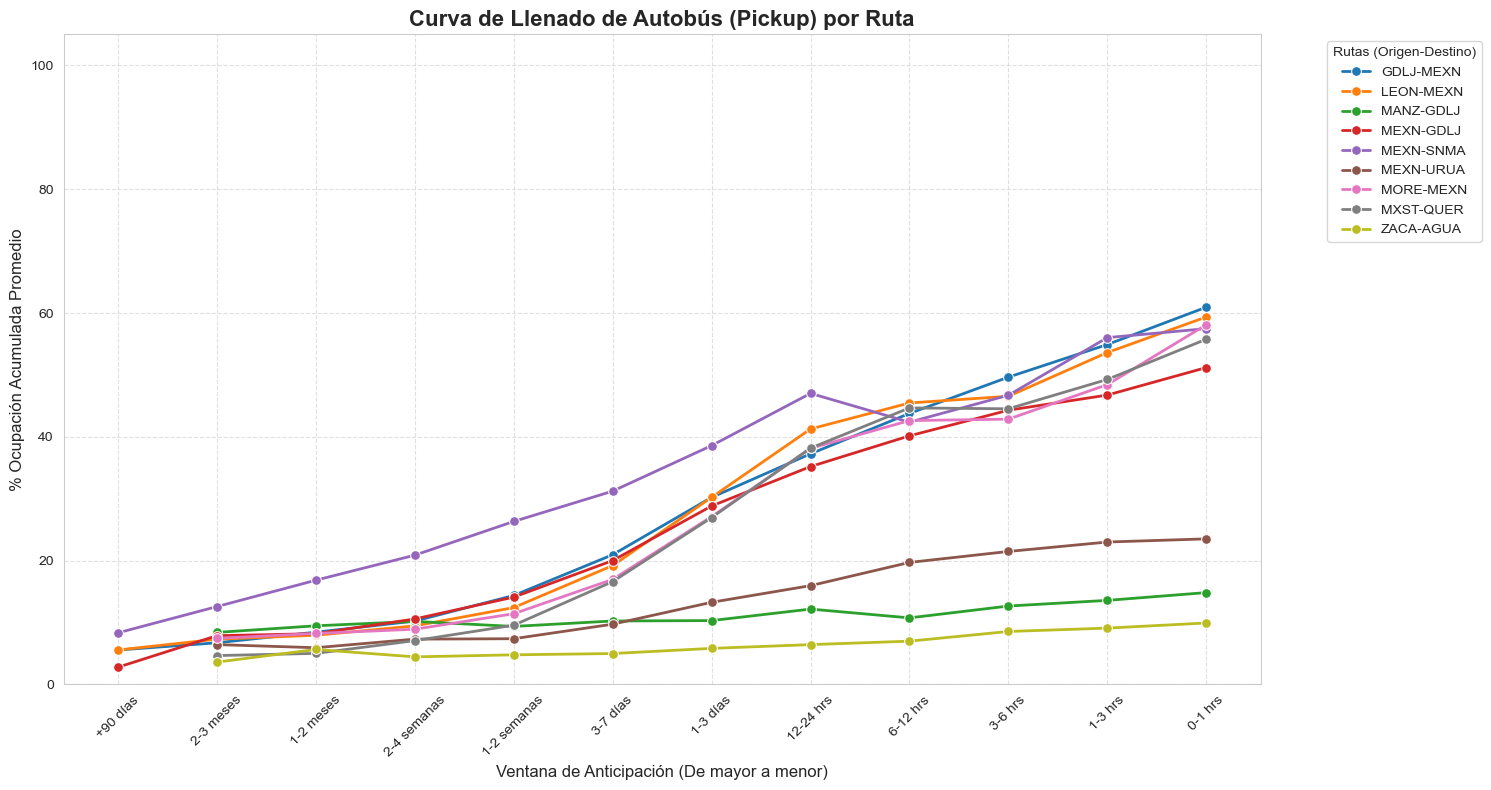

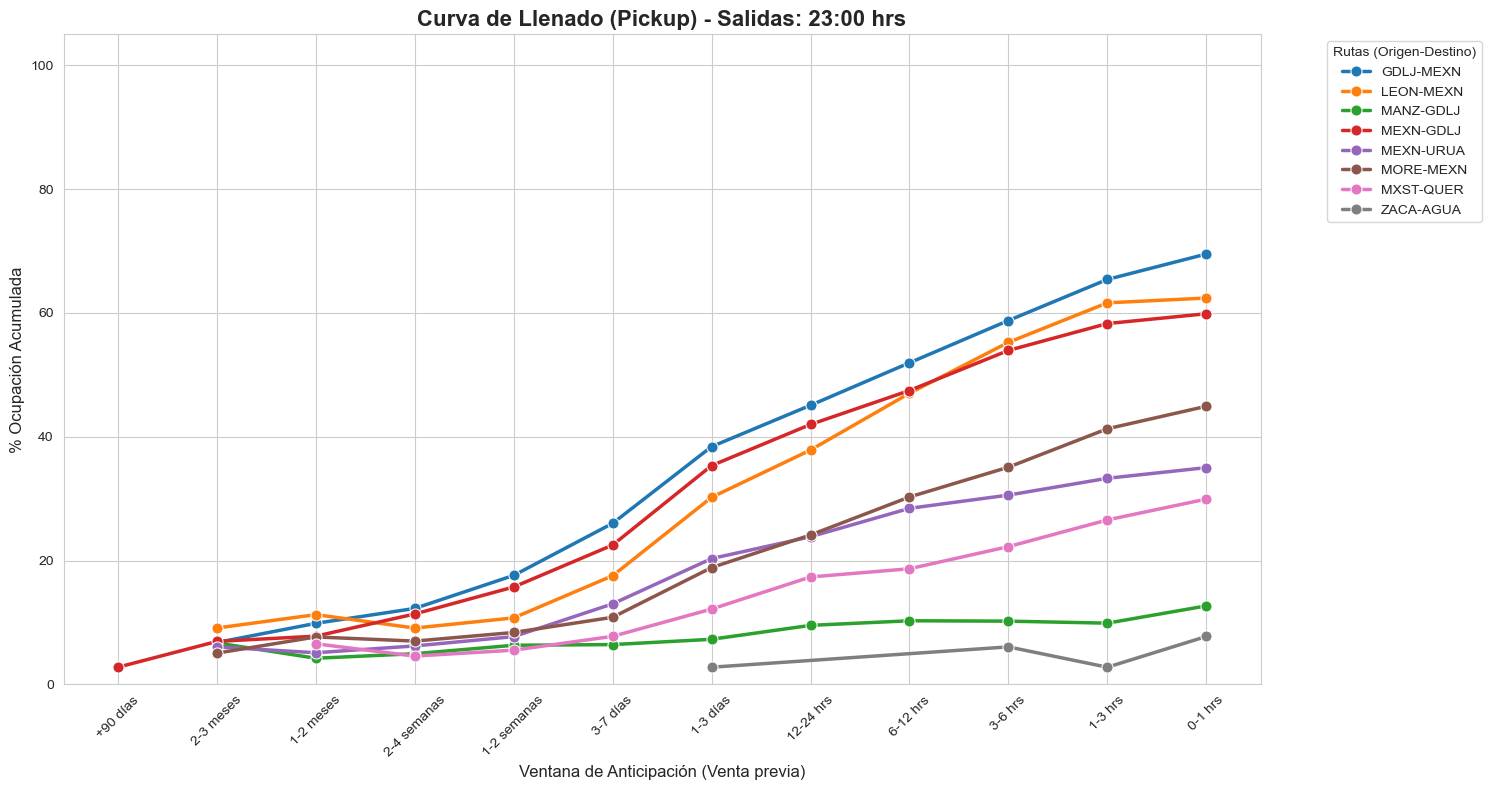

In [13]:
df_detalle, df_g,df_g1 = procesar_ocupacion_dinamica_v2(Df.copy(),'CAPACIDAD_ASIENTOS_TRAMO')
GraficarOcupacion(df_g1)
GraficarOcupacionPorHora(df_g, 23)

In [14]:
df_detalle.head(20)

,ORIGEN_DESTINO,CV_CORRIDA,FECHA_CORRIDA,HORA_ENTERA,RANGO_ANTICIPACION,BOLETOS_VEND,CAPACIDAD_ORIGINAL,Ingreso,Tarifa,VENTA_ACUMULADA,VENTA_PREVIA_ACUM,CAPACIDAD_DINAMICA,OCUPACION_INDIVIDUAL_%,OCUPACION_ACUMULADA_%
0,GDLJ-MEXN,1055007,2025-01-13,23,6-12 hrs,2.0,33.0,1677.589966,2327.580078,2.0,0.0,33.0,6.060606,6.060606
1,GDLJ-MEXN,1055007,2025-01-13,23,3-6 hrs,1.0,33.0,1078.449951,1163.790039,3.0,2.0,31.0,3.030303,9.090909
2,GDLJ-MEXN,1055007,2025-01-13,23,1-3 hrs,1.0,33.0,1078.449951,1163.790039,4.0,3.0,30.0,3.030303,12.121212
3,GDLJ-MEXN,1055007,2025-04-11,23,1-3 días,5.0,33.0,3060.350037,5818.950195,5.0,3.0,30.0,15.151515,15.151515
4,GDLJ-MEXN,1055007,2025-04-11,23,12-24 hrs,6.0,33.0,5875.860229,6982.740234,11.0,8.0,25.0,18.181818,33.333333
5,GDLJ-MEXN,1055007,2025-04-11,23,6-12 hrs,6.0,33.0,5937.070190,6982.740234,17.0,14.0,19.0,18.181818,51.515152
6,GDLJ-MEXN,1055007,2025-04-11,23,1-3 hrs,1.0,33.0,1162.930054,1163.790039,18.0,20.0,13.0,3.030303,54.545455
7,GDLJ-MEXN,1055007,2025-04-11,23,0-1 hrs,7.0,33.0,7173.270203,8146.530273,25.0,21.0,12.0,21.212121,75.757576
8,GDLJ-MEXN,1055007,2025-04-16,23,1-3 días,13.0,35.0,11518.970093,15129.270508,13.0,21.0,14.0,37.142857,37.142857
9,GDLJ-MEXN,1055007,2025-04-16,23,12-24 hrs,1.0,35.0,1171.119995,1163.790039,14.0,34.0,1.0,2.857143,40.000000


# Fase de prueba

Se toman datos de prueba para suponer como se comportaría la venta actual

In [15]:
# --- Preparación de datos fuera de la función ---
Df_3 = df.copy()
FechaPrueba= df['FECHA_CORRIDA'].max() - pd.Timedelta(days=15)
# Extraer hora y filtrar
Df_3['HORA_ENTERA'] = pd.to_datetime(Df_3['HORA_SALIDA_CORRIDA']).dt.hour
Df_p = Df_3[Df_3['FECHA_CORRIDA'] == FechaPrueba].copy()

FechaOpera= Df_p['FECHA_OPERACION'].max() - pd.Timedelta(days=10)
Df_p = Df_p[Df_p['FECHA_OPERACION'] <= FechaOpera].copy()

In [16]:
Df_p['FECHA_OPERACION'].max(),Df_p['FECHA_CORRIDA'].max()

(Timestamp('2026-03-01 00:00:00'), Timestamp('2026-03-10 00:00:00'))

In [17]:
#Df_p.to_excel('Datos2025_2.xlsx')

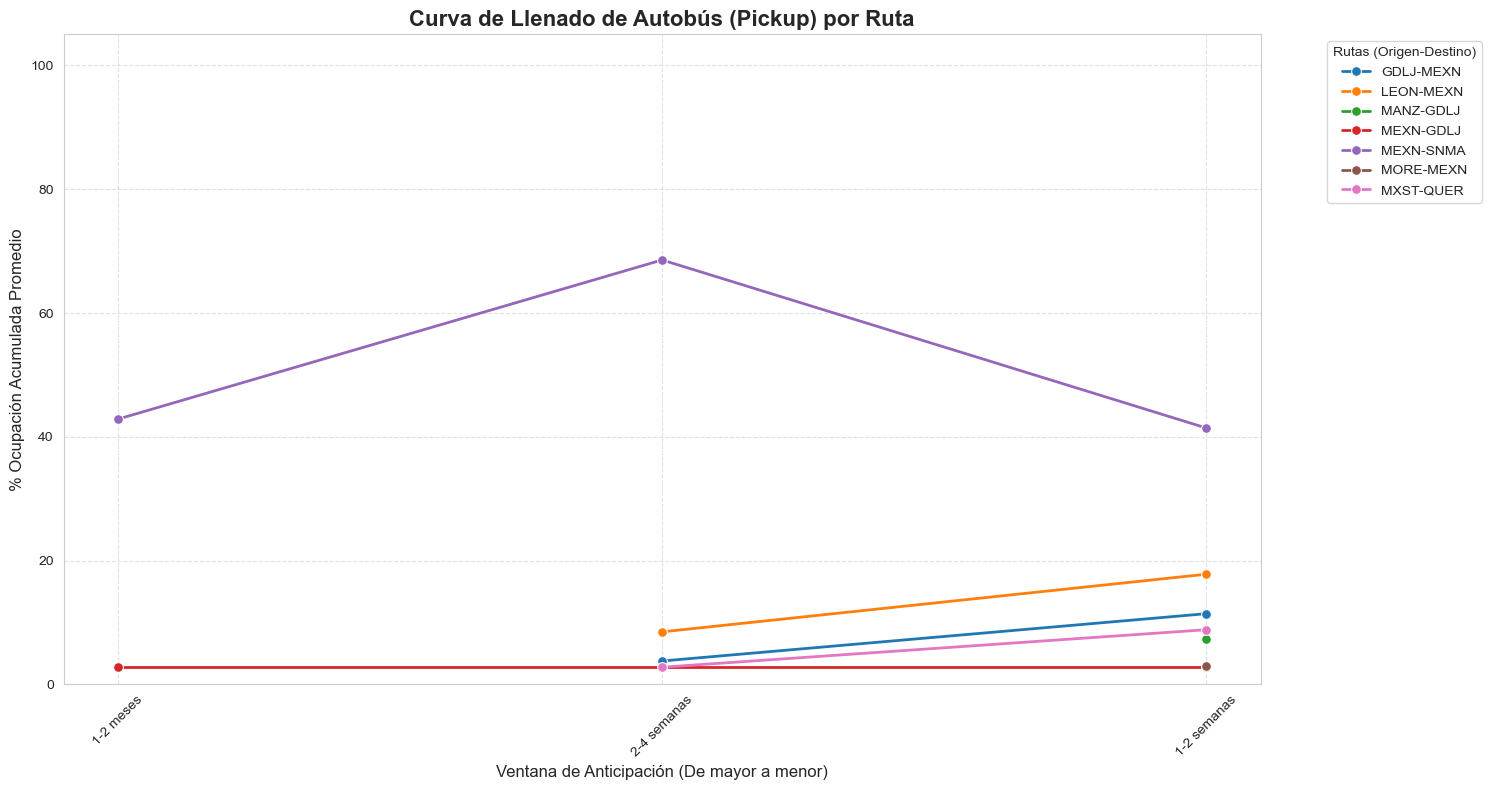

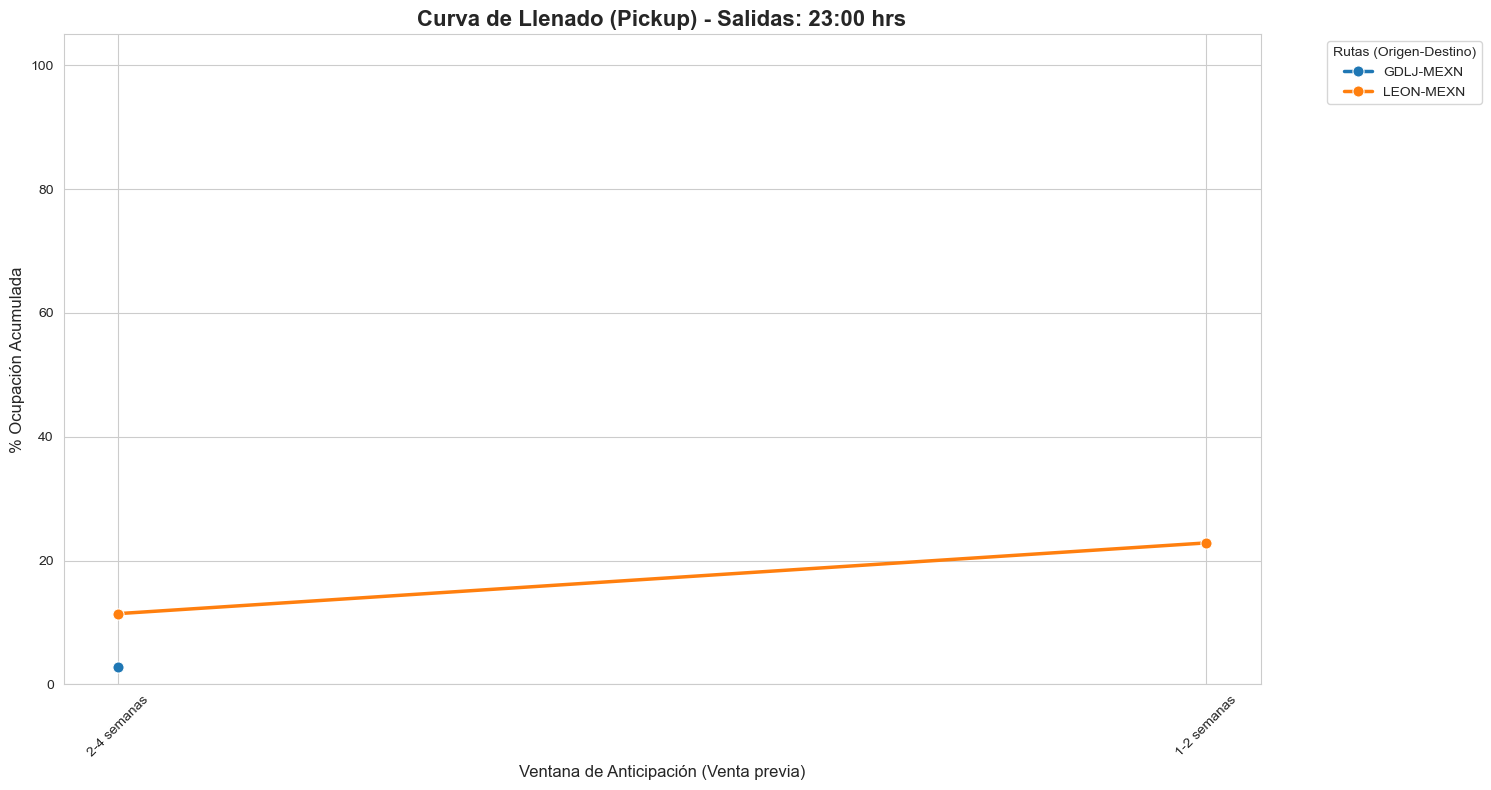

In [18]:
df_detalle_, df_g_,df_g1_ = procesar_ocupacion_dinamica_v2(Df_p.copy(),'CAPACIDAD_ASIENTOS_TRAMO')
GraficarOcupacion(df_g1_)
GraficarOcupacionPorHora(df_g_, 23)

In [19]:
def GetData4Hour(df_plot, hora_seleccionada):
    df_filtrado = df_plot[df_plot['HORA_ENTERA'] == hora_seleccionada].copy()
    df_temp = df_filtrado.copy()
    
    df_temp['RANGO_ANTICIPACION'] = pd.Categorical(
            df_temp['RANGO_ANTICIPACION'], 
            categories=orden_rangos, 
            ordered=True
        )
    return df_temp.sort_values(['ORIGEN_DESTINO', 'RANGO_ANTICIPACION'])

hora= 10
df4Hour= GetData4Hour(df_detalle_,hora)

In [20]:
def crear_indice_maestro(df, columnas_llave):
    """
    df: Puede ser df_plot (con hora) o df_plot1 (sin hora).
    columnas_llave: Lista de columnas que definen la curva (ej. ['ORIGEN_DESTINO', 'HORA_ENTERA', 'RANGO_ANTICIPACION'])
    """
    # Creamos un diccionario donde la llave es una tupla con los valores de las columnas
    return df.set_index(columnas_llave)['OCUPACION_ACUMULADA_%'].to_dict()

def proyectar_velocidad_general(datos_corrida_viva, indice_maestro, columnas_llave):
    """
    datos_corrida_viva: Un dict o fila con la info actual (Ruta, Hora, Ocupacion, Rango).
    indice_maestro: El diccionario creado arriba.
    columnas_llave: Las mismas columnas que usaste para el índice.
    """
    # 1. Construir la llave de búsqueda dinámicamente
    llave_busqueda = tuple(datos_corrida_viva[col] for col in columnas_llave)
    
    # 2. Obtener el ADN histórico
    esperado_historico = indice_maestro.get(llave_busqueda)
    
    if esperado_historico is None or esperado_historico == 0:
        return None # O manejar como "Sin Datos"

    # 3. Cálculo de Velocidad (Pace)
    ocupacion_hoy = datos_corrida_viva['OCUPACION_ACUMULADA_%']
    pace_index = ocupacion_hoy / esperado_historico
    
    # 4. Proyección de cierre
    cierre_estimado = min(100.0, 100.0 * pace_index)
    
    return {
        "Llave": llave_busqueda,
        "Pace": round(pace_index, 2),
        "Proyeccion": round(cierre_estimado, 2),
        "Desviacion": round(pace_index - 1, 2) # Negativo es "Atrasado", Positivo "Adelantado"
    }

In [21]:
llave_detallada = ['ORIGEN_DESTINO', 'HORA_ENTERA', 'RANGO_ANTICIPACION']
indice_detallado = crear_indice_maestro(df_g, llave_detallada)


# Ejemplo de corrida viva:
corrida_hoy = {'ORIGEN_DESTINO': df4Hour['ORIGEN_DESTINO'].values[0], 
               'HORA_ENTERA': hora, 'RANGO_ANTICIPACION': df4Hour['RANGO_ANTICIPACION'].values[0], 
               'OCUPACION_ACUMULADA_%': float(df4Hour['OCUPACION_ACUMULADA_%'].values[0])}

velocidad= proyectar_velocidad_general(corrida_hoy, indice_detallado, llave_detallada)
print(velocidad)

{'Llave': ('GDLJ-MEXN', 10, '2-4 semanas'), 'Pace': 0.28, 'Proyeccion': 27.79, 'Desviacion': -0.72}


In [22]:
llave_general = ['ORIGEN_DESTINO', 'RANGO_ANTICIPACION']
indice_general = crear_indice_maestro(df_g1, llave_general)

velocidad=proyectar_velocidad_general(corrida_hoy, indice_general, llave_general)
print(velocidad)

{'Llave': ('GDLJ-MEXN', '2-4 semanas'), 'Pace': 0.28, 'Proyeccion': 27.93, 'Desviacion': -0.72}


In [23]:
def agente_revenue_management(corrida_info, velocidad):
    # 1. Tomar los datos calculados
    costo = corrida_info['costo_total']
    capacidad = corrida_info['asientos_a_vender']
    tarifa_adulto = corrida_info['PrecioOptimo']
    Pace= velocidad['Pace']
    
    # 2. Lógica de Ajuste: Definir límites de descuento según el Pace
    # Si el Pace es 0.8 (frío), permitimos más descuentos para llenar.
    # Si el Pace es 1.2 (caliente), restringimos descuentos al mínimo.
    
    if Pace < 0.9:
        print("¡Alerta: Corrida fría! Abriendo cupos de descuento al máximo.")
        # Aumentamos límites
        limites_activos = {
        'estudiantes': {'factor': 0.85, 'limite': 4},
        'insen': {'factor': 0.5, 'limite': 4},
        'maestros': {'factor': 0.75, 'limite': 4},
        'ninos': {'factor': 0.5, 'limite': 4},
        'empleado_gobierno': {'factor': 0.90, 'limite': 4}}
    elif Pace > 1.1:
        print("¡Corrida caliente! Limitando descuentos para maximizar tarifa plena.")
        #Sin descuentos
        limites_activos = {
        'estudiantes': {'factor': 0.85, 'limite': 0},
        'insen': {'factor': 0.5, 'limite': 1},
        'maestros': {'factor': 0.75, 'limite': 0},
        'ninos': {'factor': 0.5, 'limite': 0},
        'empleado_gobierno': {'factor': 0.90, 'limite': 0}}
    else:
        print("¡Corrida normal! ")
        # Normal
        limites_activos = {
        'estudiantes': {'factor': 0.85, 'limite': 2},
        'insen': {'factor': 0.5, 'limite': 2},
        'maestros': {'factor': 0.75, 'limite': 2},
        'ninos': {'factor': 0.5, 'limite': 2},
        'empleado_gobierno': {'factor': 0.90, 'limite': 2}}

    # 3. Fase 2: Ejecutar el Optimizador con los nuevos límites
    resultado_mix = optimizar_mix_pasajeros_real(costo, capacidad, tarifa_adulto, limites_activos)
    
    return {
        "Pace_Index": Pace,
        "Mix_Recomendado": resultado_mix
    }

print(agente_revenue_management(resultados, velocidad))

¡Alerta: Corrida fría! Abriendo cupos de descuento al máximo.
{'Pace_Index': 0.28, 'Mix_Recomendado': {'Adultos': 16, 'Descuentos': {'estudiantes': 0, 'insen': 1, 'maestros': 0, 'ninos': 1, 'empleado_gobierno': 0}, 'Total_Pasajeros': 18, 'Ingreso_Final': 20842.0, 'Costo_a_Cubrir': 20800.0, 'Estado': 'Optimal'}}


# Calculo de la elasticidad

In [24]:
def GetElasticity(df_detalle):
    # Calculamos el Precio Promedio Real por boleto en cada registro
    df_detalle['PRECIO_PROMEDIO_PAGADO'] = df_detalle['Ingreso'] / df_detalle['BOLETOS_VEND']
    # Agrupamos para obtener la Tarifa Promedio y Ocupación por Ruta y Rango
    # Agregamos 'FECHA_CORRIDA' (por mes o semana) para tener puntos de comparación
    df_detalle['MES'] = pd.to_datetime(df_detalle['FECHA_CORRIDA']).dt.to_period('M')
    
    # Ahora, cuando agrupes para la elasticidad, usa esta nueva variable
    df_elasticidad = df_detalle.groupby(['ORIGEN_DESTINO', 'RANGO_ANTICIPACION', 'MES'], observed=True).agg({
        'PRECIO_PROMEDIO_PAGADO': 'mean', # Este es tu P real
        'OCUPACION_INDIVIDUAL_%': 'mean'  # Este es tu Q real
    }).reset_index()
    
    # Aseguramos el orden cronológico para que el pct_change tenga sentido
    df_elasticidad = df_elasticidad.sort_values(['ORIGEN_DESTINO', 'RANGO_ANTICIPACION', 'MES'])
    
    # Calculamos la variación porcentual de P y Q
    # Agrupamos por Ruta y Rango para que no compare la última fila de una ruta con la primera de otra
    df_elasticidad['delta_P'] = df_elasticidad.groupby(['ORIGEN_DESTINO', 'RANGO_ANTICIPACION'])['PRECIO_PROMEDIO_PAGADO'].pct_change()
    df_elasticidad['delta_Q'] = df_elasticidad.groupby(['ORIGEN_DESTINO', 'RANGO_ANTICIPACION'])['OCUPACION_INDIVIDUAL_%'].pct_change()
    
    # Calcular la Elasticidad Punto a Punto
    df_elasticidad['elasticidad_punto'] = df_elasticidad['delta_Q'] / df_elasticidad['delta_P']
    
    #  Eliminar infinitos y nulos
    df_clean = df_elasticidad.replace([np.inf, -np.inf], np.nan).dropna(subset=['elasticidad_punto'])
    
    # Filtrar Outliers: En transporte, una elasticidad lógica suele estar entre -5 y 0.
    # Si te da +10, es ruido (el precio subió y la demanda también por un festival, por ejemplo).
    df_final_elasticidad = df_clean[df_clean['elasticidad_punto'].between(-5, 0)]
    
    # Usamos la mediana para ser más robustos contra valores extremos
    tabla_maestra_elasticidad = df_final_elasticidad.groupby(['ORIGEN_DESTINO', 'RANGO_ANTICIPACION'])['elasticidad_punto'].median().reset_index()
    
    # Re-ordenar según tus etiquetas de anticipación
    orden_rangos = ['+90 días', '2-3 meses', '1-2 meses', '2-4 semanas', '1-2 semanas', 
                    '3-7 días', '1-3 días', '12-24 hrs', '6-12 hrs', '3-6 hrs', '1-3 hrs', '0-1 hrs']
    tabla_maestra_elasticidad['RANGO_ANTICIPACION'] = pd.Categorical(tabla_maestra_elasticidad['RANGO_ANTICIPACION'], categories=orden_rangos, ordered=True)
    tabla_maestra_elasticidad = tabla_maestra_elasticidad.sort_values(['ORIGEN_DESTINO', 'RANGO_ANTICIPACION'])
    
    tabla_maestra_elasticidad= tabla_maestra_elasticidad.dropna(subset=['RANGO_ANTICIPACION'])
    tabla_maestra_elasticidad['elasticidad_punto']= tabla_maestra_elasticidad['elasticidad_punto'].fillna(0)

    return tabla_maestra_elasticidad

In [25]:
tabla_maestra_elasticidad= GetElasticity(df_detalle.copy())
tabla_maestra_elasticidad.head(20)

,ORIGEN_DESTINO,RANGO_ANTICIPACION,elasticidad_punto
0,GDLJ-MEXN,+90 días,0.000000
1,GDLJ-MEXN,2-3 meses,-1.624434
2,GDLJ-MEXN,1-2 meses,-1.617606
3,GDLJ-MEXN,2-4 semanas,-0.491187
4,GDLJ-MEXN,1-2 semanas,-1.741615
5,GDLJ-MEXN,3-7 días,-1.126917
6,GDLJ-MEXN,1-3 días,-0.282204
7,GDLJ-MEXN,12-24 hrs,-0.381646
8,GDLJ-MEXN,6-12 hrs,-0.558031
9,GDLJ-MEXN,3-6 hrs,-1.030130
